Phase testing between the open ephys gui phase calculator and the Bonsai phase calculator 

In [24]:
from glob import glob
import os

import numpy as np
import pandas as pd
from scipy import stats, signal
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from open_ephys.analysis import Session

In [3]:
%matplotlib widget
plt.close('all')

def edge(data, thresh, edge):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == edge)
    return pos

def to_binary(num):
    word = bin(int(num))[2:].zfill(8)
    return map(int, word)

In [4]:
folder = 'C:\\Users\\Leah\\Documents\\OnixData\\PhaseTesting\\phase-test-2025-7-31\\'

suffix = '0'

ONIX Data 

In [11]:
dtMeta = {'names': ('time', 'acq_clk_hz', 'block_read_sz', 'block_write_sz'),
      'formats': ('datetime64[us]', 'u4', 'u4', 'u4')}
meta = np.genfromtxt(folder + 'start-time_' + suffix + '.csv', delimiter=',', dtype=dtMeta)
print(f"Recording was started at {meta['time']} GMT")

analog_input = {}
analog_input['time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64) / meta['acq_clk_hz']
analog_input['raw_time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64)
analog_input['data'] = np.fromfile(folder + 'analog-data_' + suffix + '.raw', dtype=np.float32)

onix_phase = np.genfromtxt(folder + 'prediction_' + suffix + '.csv', delimiter=',') 

Recording was started at 2025-08-01T16:36:40.471603 GMT


(1000, 100)


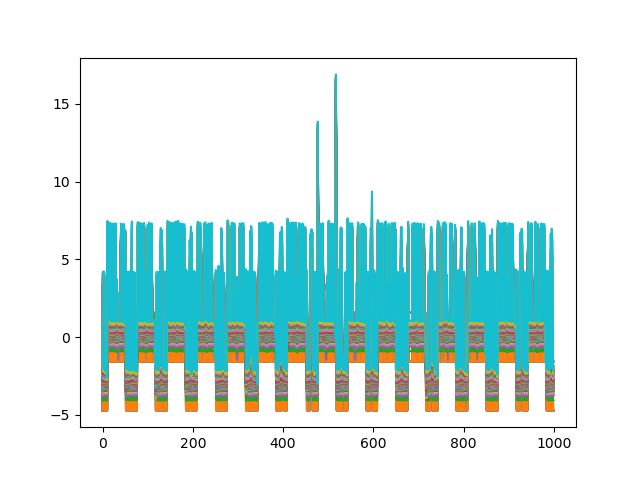

In [22]:
chan = onix_phase[0:1000,]
print(chan.shape)

plt.figure()
plt.plot(chan)
plt.show()

OE GUI

In [5]:
# alpha_theta_phase = Session((folder + 'phase_test_alpha_theta_2025-07-23_15-24-13'))
# beta_phase = Session((folder + 'phase_test_beta_2025-07-23_15-27-32'))
# low_gamma_phase = Session((folder + 'phase_test_low_gamma_2025-07-23_15-29-41'))
# mid_gamma_phase = Session((folder + 'phase_test_mid_gamma_2025-07-23_15-30-58'))

oe_data = Session(folder + '2025-07-31_14-34-41')

In [33]:
# Get phase and raw data from OE GUI (old and bad)
# alpha theta
# alpha_theta_phase_record_node_0 = alpha_theta_phase.recordnodes[0].recordings[0]
# alpha_theta_phase_raw_data = alpha_theta_phase_record_node_0.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# alpha_theta_phase_record_node_1 = alpha_theta_phase.recordnodes[1].recordings[0]
# alpha_theta_phase_data = alpha_theta_phase_record_node_1.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# # beta 
# beta_phase_record_node_0 = beta_phase.recordnodes[0].recordings[0]
# beta_phase_raw_data = beta_phase_record_node_0.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# beta_phase_record_node_1 = beta_phase.recordnodes[1].recordings[0]
# beta_phase_data = beta_phase_record_node_1.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# # low gamma 
# low_gamma_phase_record_node_0 = low_gamma_phase.recordnodes[0].recordings[0]
# low_gamma_phase_raw_data = low_gamma_phase_record_node_0.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# low_gamma_phase_record_node_1 = low_gamma_phase.recordnodes[1].recordings[0]
# low_gamma_phase_data = low_gamma_phase_record_node_1.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# # mid gamma
# mid_gamma_phase_record_node_0 = mid_gamma_phase.recordnodes[0].recordings[0]
# mid_gamma_phase_raw_data = mid_gamma_phase_record_node_0.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# mid_gamma_phase_record_node_1 = mid_gamma_phase.recordnodes[1].recordings[0]
# mid_gamma_phase_data = mid_gamma_phase_record_node_1.continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

# Get phase and raw data from OE GUI 
oe_phase_data = oe_data.recordnodes[0].recordings[1].continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)
oe_raw_data = oe_data.recordnodes[1].recordings[1].continuous[0].get_samples(start_sample_index=0, end_sample_index=10000)

oe_raw_chan = np.subtract(oe_raw_data[:,1], np.mean(oe_raw_data[:,1]))


In [36]:
hilb = signal.hilbert(oe_raw_chan)

samples_per_period = int(30000 / 15)

unwrapped_phase = np.unwrap(np.angle(hilb))

n_periods = len(oe_raw_chan) // samples_per_period
phases_by_period = []

for i in range(n_periods):
    start = i * samples_per_period
    end = start + samples_per_period
    phase_segment = unwrapped_phase[start:end]
    phases_by_period.append(phase_segment)
    
phases_by_period = np.array(phases_by_period) 

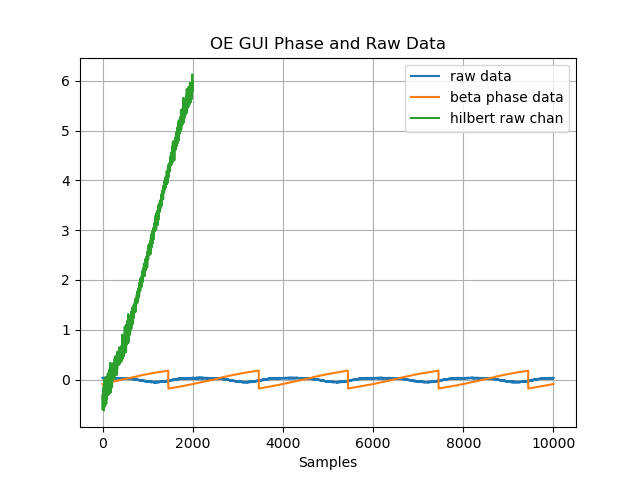

In [37]:
plt.figure()
plt.plot(oe_raw_chan, label='raw data')
# plt.plot(oe_phase_data[:,3], label='theta phase data')
plt.plot(oe_phase_data[:,4], label='beta phase data')
# plt.plot(oe_phase_data[:,5], label='low gamma phase data')
# plt.plot(oe_phase_data[:,6], label='mid gamma phase data')
# plt.plot(oe_phase_data[:,7], label='high gamma phase data')
plt.plot(phases_by_period[0], label='hilbert raw chan')
plt.legend()
plt.title("OE GUI Phase and Raw Data")
plt.xlabel("Samples")
plt.grid(True)
plt.show()


In [ ]:
# Onix OE Phase Plug in (Not working)
df = pd.read_csv("C:\\Users\\Leah\\Documents\\OnixData\\PhaseTesting\\phase-test-2025-7-23\\prediction_0.csv", header=None)

slider = widgets.IntSlider(value=1, min=1, max=len(df), step=1, description='Line #:')

def plot_row(line_number):
    row_data = df.iloc[line_number - 1]
    plt.figure(figsize=(12, 4))
    row_data.plot()
    plt.title(f"Plot of data from line {line_number}")
    plt.xlabel("Column Index")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

widgets.interact(plot_row, line_number=slider)